In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [76]:
data = pd.read_csv("/Users/pablomon/Programacion/PersonalPython/Portfolio/ProyectoComp/data/logistics_dataset_2020_2024.csv")

In [77]:
data['date'] = pd.to_datetime(data['date'])
data.set_index('date', inplace=True)
data['diff_7'] = data['order_volume'].diff(7)

In [78]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1461 entries, 2020-01-01 to 2023-12-31
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   holiday_flag           1461 non-null   int64  
 1   promo_flag             1461 non-null   int64  
 2   order_volume           1461 non-null   int64  
 3   delivery_count         1461 non-null   int64  
 4   inventory_level        1461 non-null   float64
 5   lead_time_avg          1461 non-null   float64
 6   warehouse_utilization  1461 non-null   float64
 7   vehicle_availability   1461 non-null   int64  
 8   fuel_price_index       1461 non-null   float64
 9   economic_index         1461 non-null   float64
 10  temperature            1461 non-null   float64
 11  rainfall_mm            1461 non-null   float64
 12  lag_1_order            1460 non-null   float64
 13  lag_7_order            1454 non-null   float64
 14  lag_30_order           1431 non-null   float64
 1

In [79]:
data.head()

,holiday_flag,promo_flag,order_volume,delivery_count,inventory_level,lead_time_avg,warehouse_utilization,vehicle_availability,fuel_price_index,economic_index,...,rainfall_mm,lag_1_order,lag_7_order,lag_30_order,rolling_mean_7,rolling_std_7,month,day_of_week,quarter,diff_7
date,,,,,,,,,,,,,,,,,,,,,
2020-01-01,0,0,386,378,14632.272811,2.299479,0.674300,29,85.007023,65.268022,...,1.777166,NaN,NaN,NaN,NaN,NaN,1,2,1,NaN
2020-01-02,0,1,421,397,14689.541483,2.029979,0.757457,23,85.006682,65.620257,...,9.679653,386.0,NaN,NaN,NaN,NaN,1,3,1,NaN
2020-01-03,0,0,420,405,14958.120986,2.505207,0.585171,37,85.000944,65.624186,...,4.145198,421.0,NaN,NaN,NaN,NaN,1,4,1,NaN
2020-01-04,0,0,399,384,15014.205900,2.962284,0.624174,32,85.045117,65.949640,...,1.391314,420.0,NaN,NaN,NaN,NaN,1,5,1,NaN
2020-01-05,1,0,446,431,15240.210289,2.729617,0.702982,32,85.021849,65.464262,...,0.318981,399.0,NaN,NaN,NaN,NaN,1,6,1,NaN


In [80]:
data.describe()

,holiday_flag,promo_flag,order_volume,delivery_count,inventory_level,lead_time_avg,warehouse_utilization,vehicle_availability,fuel_price_index,economic_index,...,rainfall_mm,lag_1_order,lag_7_order,lag_30_order,rolling_mean_7,rolling_std_7,month,day_of_week,quarter,diff_7
count,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000,...,1461.000000,1460.000000,1454.000000,1431.000000,1455.000000,1455.000000,1461.000000,1461.000000,1461.000000,1454.000000
mean,0.143053,0.103354,406.139630,391.228611,5825.716288,2.487122,0.730598,29.670089,85.885388,50.255416,...,4.451179,406.147260,406.239340,406.136268,406.175749,21.750437,6.522930,3.003422,2.508556,-0.153370
std,0.350246,0.304525,28.035686,28.679042,6731.004332,0.403009,0.104318,5.763429,0.350656,9.783896,...,3.359707,28.043774,28.049346,28.179649,18.717576,5.994911,3.449884,1.999826,1.117465,26.385657
min,0.000000,0.000000,327.000000,309.000000,-4184.746808,1.800337,0.550020,20.000000,84.886698,28.813700,...,0.000287,327.000000,327.000000,327.000000,358.857143,4.913538,1.000000,0.000000,1.000000,-82.000000
25%,0.000000,0.000000,387.000000,371.000000,-65.593753,2.142602,0.643315,25.000000,85.629359,43.738214,...,1.862543,387.000000,387.000000,387.000000,389.785714,17.447881,4.000000,1.000000,2.000000,-18.000000
50%,0.000000,0.000000,406.000000,391.000000,4427.946778,2.479358,0.727891,30.000000,85.956776,53.159942,...,3.692366,406.000000,406.000000,405.000000,406.285714,21.598060,7.000000,3.000000,3.000000,0.000000
75%,0.000000,0.000000,425.000000,410.000000,10820.451661,2.835265,0.816730,35.000000,86.116257,57.609366,...,6.350301,425.000000,425.000000,425.000000,423.428571,25.686758,10.000000,5.000000,4.000000,18.000000
max,1.000000,1.000000,495.000000,483.000000,20290.663995,3.198890,0.918886,39.000000,86.683510,66.994582,...,19.144552,495.000000,495.000000,495.000000,443.857143,40.141417,12.000000,6.000000,4.000000,89.000000


In [81]:
data.isnull().sum()

holiday_flag              0
promo_flag                0
order_volume              0
delivery_count            0
inventory_level           0
lead_time_avg             0
warehouse_utilization     0
vehicle_availability      0
fuel_price_index          0
economic_index            0
temperature               0
rainfall_mm               0
lag_1_order               1
lag_7_order               7
lag_30_order             30
rolling_mean_7            6
rolling_std_7             6
month                     0
day_of_week               0
quarter                   0
diff_7                    7
dtype: int64

Tenemos 1461 entradas, podemos observar que faltan los valores de las primeras fechas en las columnas que hacen referencia a datos pasados. Como tenemos sufucientes datos, **eliminar las 30 primeras filas** no supondrá una pérdida significativa de información

In [82]:
data.dropna(inplace=True)

In [83]:
data.head()

,holiday_flag,promo_flag,order_volume,delivery_count,inventory_level,lead_time_avg,warehouse_utilization,vehicle_availability,fuel_price_index,economic_index,...,rainfall_mm,lag_1_order,lag_7_order,lag_30_order,rolling_mean_7,rolling_std_7,month,day_of_week,quarter,diff_7
date,,,,,,,,,,,,,,,,,,,,,
2020-01-31,0,0,384,376,16304.614332,2.497465,0.635599,30,84.943943,62.542531,...,3.910586,452.0,417.0,386.0,423.571429,26.031117,1,4,1,-33.0
2020-02-01,0,0,412,398,16061.269622,2.261343,0.600457,20,84.978851,63.304299,...,2.803427,384.0,400.0,421.0,425.285714,24.574474,2,5,1,12.0
2020-02-02,1,0,461,452,16313.052956,2.416844,0.622775,29,84.961290,62.557209,...,10.073916,412.0,447.0,420.0,427.285714,27.078370,2,6,1,14.0
2020-02-03,0,1,460,446,16397.089197,2.999730,0.570473,39,84.948467,63.371781,...,8.723426,461.0,427.0,399.0,432.000000,29.760152,2,0,1,33.0
2020-02-04,0,1,431,415,16340.220132,2.757893,0.623308,30,84.911379,63.285632,...,5.256655,460.0,411.0,446.0,434.857143,28.333894,2,1,1,20.0


In [84]:
data.isnull().sum()

holiday_flag             0
promo_flag               0
order_volume             0
delivery_count           0
inventory_level          0
lead_time_avg            0
warehouse_utilization    0
vehicle_availability     0
fuel_price_index         0
economic_index           0
temperature              0
rainfall_mm              0
lag_1_order              0
lag_7_order              0
lag_30_order             0
rolling_mean_7           0
rolling_std_7            0
month                    0
day_of_week              0
quarter                  0
diff_7                   0
dtype: int64

In [85]:
df = data.copy()
df = df.asfreq('D')
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1431 entries, 2020-01-31 to 2023-12-31
Freq: D
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   holiday_flag           1431 non-null   int64  
 1   promo_flag             1431 non-null   int64  
 2   order_volume           1431 non-null   int64  
 3   delivery_count         1431 non-null   int64  
 4   inventory_level        1431 non-null   float64
 5   lead_time_avg          1431 non-null   float64
 6   warehouse_utilization  1431 non-null   float64
 7   vehicle_availability   1431 non-null   int64  
 8   fuel_price_index       1431 non-null   float64
 9   economic_index         1431 non-null   float64
 10  temperature            1431 non-null   float64
 11  rainfall_mm            1431 non-null   float64
 12  lag_1_order            1431 non-null   float64
 13  lag_7_order            1431 non-null   float64
 14  lag_30_order           1431 non-null   fl

In [86]:
df.size-data.size
# Tienen mismo numero de filas, por lo que no falta ningun dato.

0

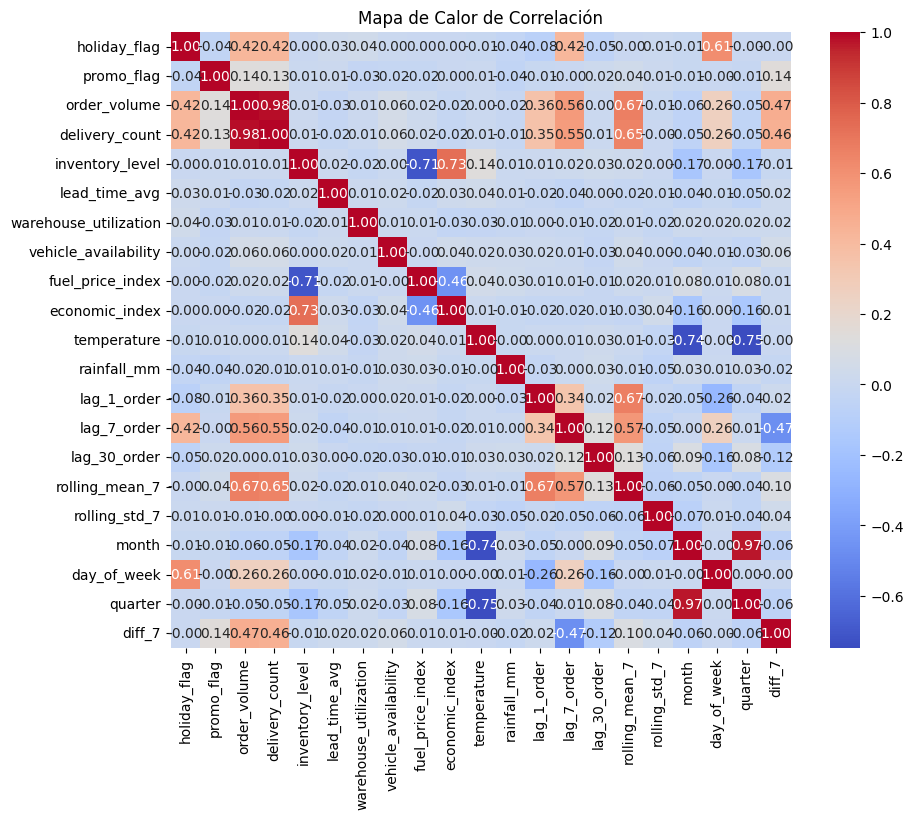

In [87]:
# Mapa de calor de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor de Correlación')
plt.show()

Como es logico, el **delivery_count** y el **order_volume** tienen una fuerte correlación, nuestro objetivo será predecir ambas variables.

# Analizamos periodicidad

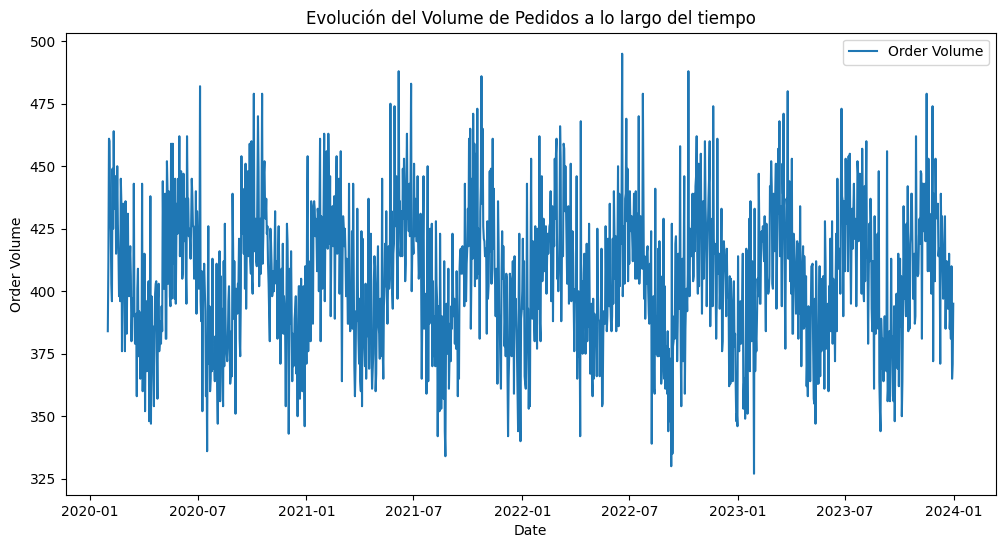

In [88]:
# Visualización de todas variables a lo largo del tiempo
plt.figure(figsize=(12, 6))
plt.plot(df['order_volume'], label='Order Volume')
plt.xlabel('Date')
plt.ylabel('Order Volume')
plt.title('Evolución del Volume de Pedidos a lo largo del tiempo')
plt.legend()
plt.show()


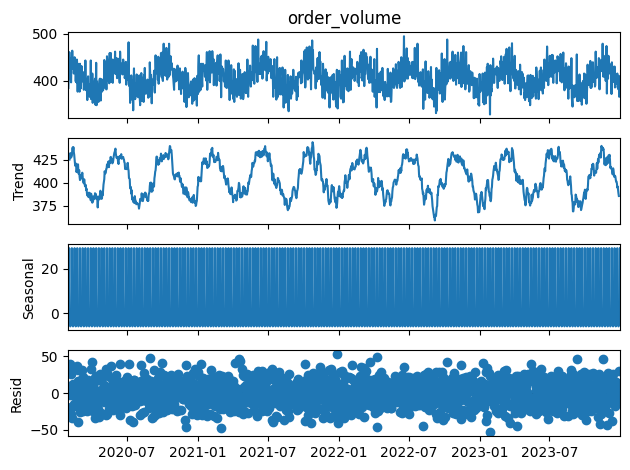

In [89]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Aplicamos la descomposición
# Usamos model='multiplicative' si los picos crecen con el tiempo, 
# o 'additive' si los picos mantienen un tamaño constante.
descomposicion = seasonal_decompose(df['order_volume'], model='additive')

# Graficamos los componentes
descomposicion.plot()
plt.show()

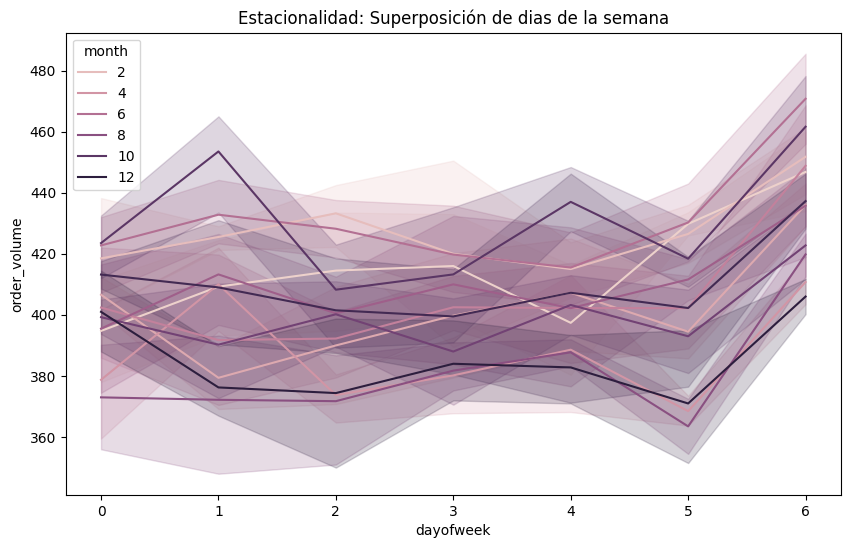

In [90]:
# Creamos columnas auxiliares
df['year'] = df.index.year
df['month'] = df.index.month
df['dayofweek'] = df.index.dayofweek

plt.figure(figsize=(10,6))
sns.lineplot(data=df[df['year']==2021], x='dayofweek', y='order_volume', hue='month', legend=True)
plt.title('Estacionalidad: Superposición de dias de la semana')
plt.show()

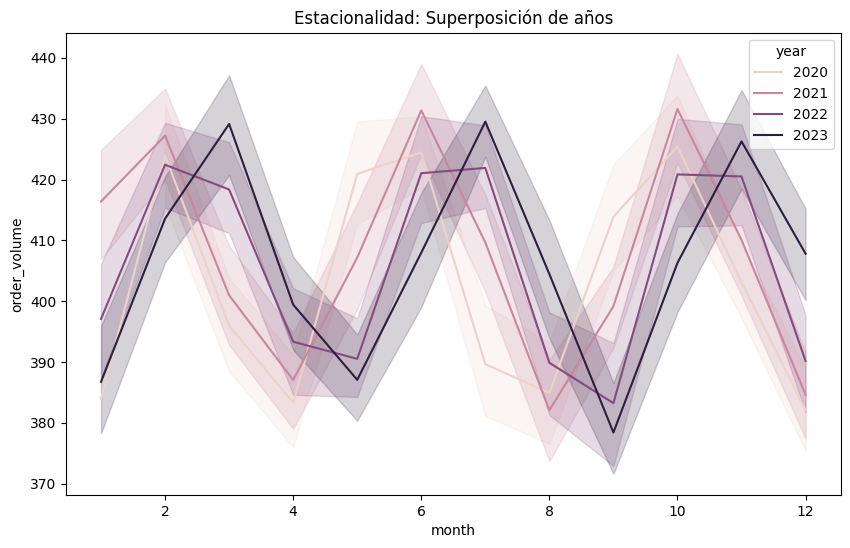

In [91]:
# Creamos columnas auxiliares
df['year'] = df.index.year
df['month'] = df.index.month

plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='month', y='order_volume', hue='year', legend=True)
plt.title('Estacionalidad: Superposición de años')
plt.show()

## Preparación de datos

In [92]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1431 entries, 2020-01-31 to 2023-12-31
Freq: D
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   holiday_flag           1431 non-null   int64  
 1   promo_flag             1431 non-null   int64  
 2   order_volume           1431 non-null   int64  
 3   delivery_count         1431 non-null   int64  
 4   inventory_level        1431 non-null   float64
 5   lead_time_avg          1431 non-null   float64
 6   warehouse_utilization  1431 non-null   float64
 7   vehicle_availability   1431 non-null   int64  
 8   fuel_price_index       1431 non-null   float64
 9   economic_index         1431 non-null   float64
 10  temperature            1431 non-null   float64
 11  rainfall_mm            1431 non-null   float64
 12  lag_1_order            1431 non-null   float64
 13  lag_7_order            1431 non-null   float64
 14  lag_30_order           1431 non-null   fl

In [93]:
train = df[df.index < '2023-10-01']
test = df[df.index >= '2023-10-01']
# Definimos el Target
target = 'order_volume'

# Definimos los Features seleccionados
features = [
    'lag_1_order', 'lag_7_order', 'lag_30_order', # Historia
    'rolling_mean_7', 'rolling_std_7',            # Tendencia
    'holiday_flag', 'promo_flag',                 # Eventos
    'month', 'dayofweek', 'quarter',              # Tiempo
    'temperature', 'rainfall_mm',                 # Clima
    'fuel_price_index', 'economic_index'          # Macroeconomía
]

X_train = train[features]
X_test = test[features]
y_train = train[target]
y_test = test[target]

## Predicciones

In [106]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
# 3. Crear y entrenar el modelo
modelo = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.01, max_depth=5)
modelo.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)

# 4. Predecir
predicciones = modelo.predict(X_test)

[0]	validation_0-rmse:25.38129
[100]	validation_0-rmse:17.95425
[200]	validation_0-rmse:16.75789
[300]	validation_0-rmse:16.54551
[400]	validation_0-rmse:16.33183
[500]	validation_0-rmse:16.39444
[600]	validation_0-rmse:16.43440
[700]	validation_0-rmse:16.65275
[800]	validation_0-rmse:16.82261
[900]	validation_0-rmse:16.99034
[999]	validation_0-rmse:17.19718


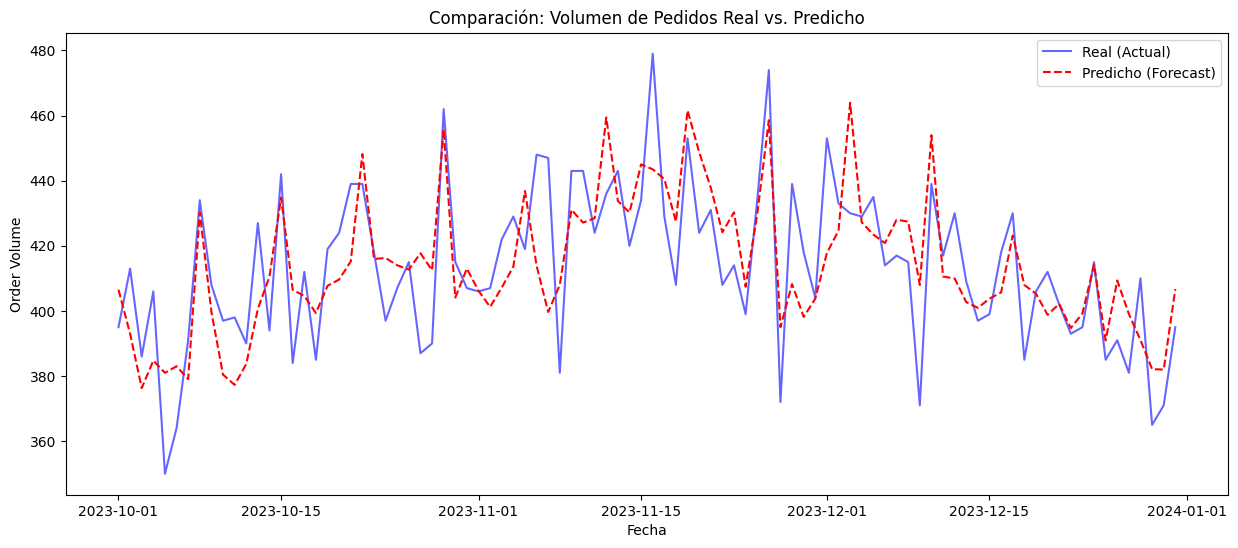

In [107]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

# Graficamos los datos reales del set de prueba
plt.plot(y_test.index, y_test.values, label='Real (Actual)', color='blue', alpha=0.6)

# Graficamos las predicciones
plt.plot(y_test.index, predicciones, label='Predicho (Forecast)', color='red', linestyle='--')

plt.title('Comparación: Volumen de Pedidos Real vs. Predicho')
plt.xlabel('Fecha')
plt.ylabel('Order Volume')
plt.legend()
plt.show()

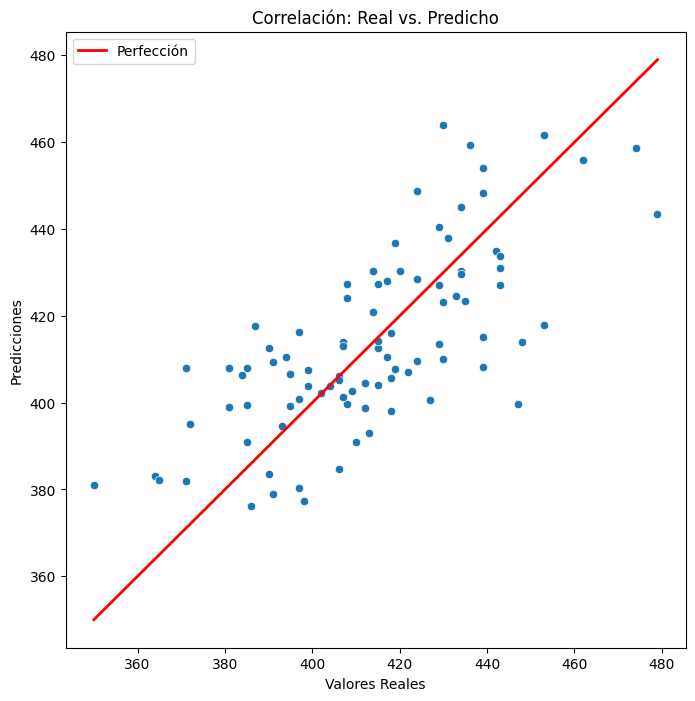

In [108]:
import seaborn as sns

plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test.values, y=predicciones)

# Dibujamos la línea de perfección (x = y)
lims = [min(y_test.min(), predicciones.min()), max(y_test.max(), predicciones.max())]
plt.plot(lims, lims, color='red', lw=2, label='Perfección')

plt.title('Correlación: Real vs. Predicho')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.legend()
plt.show()

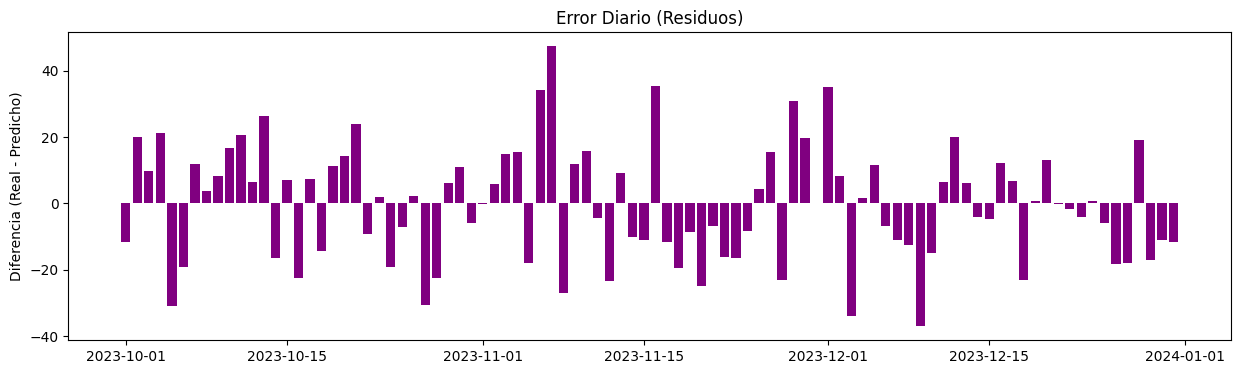

In [109]:
error = y_test.values - predicciones
plt.figure(figsize=(15, 4))
plt.bar(y_test.index, error, color='purple')
plt.title('Error Diario (Residuos)')
plt.ylabel('Diferencia (Real - Predicho)')
plt.show()